In [ ]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Step 2: Check current working directory
print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
c:\Users\Admin\hand_gesture_project


In [5]:
import pandas as pd
df = pd.read_csv("Housing.csv")

In [8]:
print(df.columns)


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [10]:
# Step 3: Display first 5 rows
print("First 5 rows of dataset:")
print(df.head())

First 5 rows of dataset:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [11]:
# Step 4: Check dataset info
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB
None


In [12]:
# Step 5: Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [13]:

# Step 6: Select required columns
# Adjust column names if your dataset is different
X = df[['area', 'bedrooms', 'bathrooms']]
y = df['price']

In [15]:
# Step 7: Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
# Step 8: Create Linear Regression model
model = LinearRegression()

In [19]:

# Step 9: Train the model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
# Step 10: Make predictions
y_pred = model.predict(X_test)

In [21]:
# Step 11: Print model coefficients
print("\nModel Coefficients:")
print("Area coefficient:", model.coef_[0])
print("Bedrooms coefficient:", model.coef_[1])
print("Bathrooms coefficient:", model.coef_[2])

print("\nModel Intercept:")
print(model.intercept_)


Model Coefficients:
Area coefficient: 345.4665700831111
Bedrooms coefficient: 360197.6504575056
Bathrooms coefficient: 1422319.6576414115

Model Intercept:
59485.379208717495


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [25]:
# Step 12: Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)  

print("\nModel Evaluation:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)


Model Evaluation:
Mean Absolute Error (MAE): 1265275.6699454375
Mean Squared Error (MSE): 2750040479309.052
Root Mean Squared Error (RMSE): 1658324.6001036866
R2 Score: 0.45592991188724463


In [26]:
# Step 13: Compare Actual vs Predicted
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print("\nActual vs Predicted Prices:")
print(results.head(10))



Actual vs Predicted Prices:
   Actual Price  Predicted Price
0       4060000     6.383168e+06
1       6650000     6.230250e+06
2       3710000     3.597885e+06
3       6440000     4.289731e+06
4       2800000     3.930446e+06
5       4900000     4.883933e+06
6       5250000     5.505773e+06
7       4543000     6.068793e+06
8       2450000     3.321512e+06
9       3353000     3.495158e+06


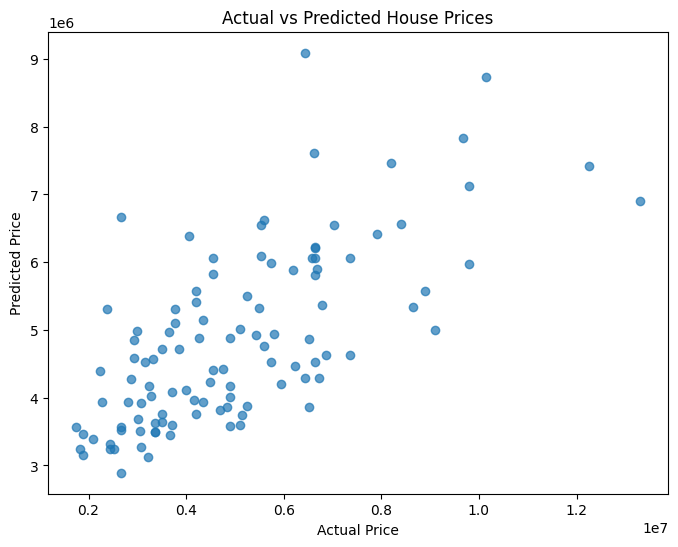

In [27]:
# Step 14: Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()


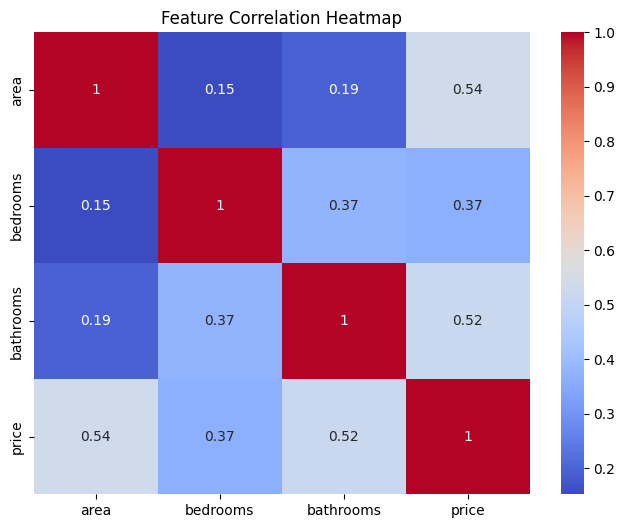

In [28]:
# Step 15: Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[['area', 'bedrooms', 'bathrooms', 'price']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [30]:
# Step 16: Predict for a new house
new_house = pd.DataFrame({
    'area': [2500],
    'bedrooms': [3],
    'bathrooms': [2]
})

predicted_price = model.predict(new_house)
print("\nPredicted Price for New House:")
print("Area = 2500, Bedrooms = 3, Bathrooms = 2")
print("Predicted House Price:", predicted_price[0])


Predicted Price for New House:
Area = 2500, Bedrooms = 3, Bathrooms = 2
Predicted House Price: 4848384.071071835


In [31]:
from sklearn.metrics import r2_score

accuracy = r2_score(y_test, y_pred)
print("Accuracy (R2 Score):", accuracy)

Accuracy (R2 Score): 0.45592991188724463
